In [ ]:
# Run if needed 
# %pip install opencv-python

  Using cached opencv_python-4.13.0.90-cp37-abi3-macosx_13_0_arm64.whl.metadata (19 kB)
Using cached opencv_python-4.13.0.90-cp37-abi3-macosx_13_0_arm64.whl (46.0 MB)
Note: you may need to restart the kernel to use updated packages.


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MultiLabelBinarizer
import cv2
import glob
import seaborn as sns
pd.set_option('display.max_columns', None)
%matplotlib inline

# Data_Entry_2017.csv

In [3]:
data_entry_2017_path = 'Data_Entry_2017.csv'
df = pd.read_csv(data_entry_2017_path)
df.head()

,Image Index,Finding Labels,Follow-up #,Patient ID,Patient Age,Patient Gender,View Position,OriginalImage[Width,Height],OriginalImagePixelSpacing[x,y],Unnamed: 11
0,00000001_000.png,Cardiomegaly,0,1,58,M,PA,2682,2749,0.143,0.143,NaN
1,00000001_001.png,Cardiomegaly|Emphysema,1,1,58,M,PA,2894,2729,0.143,0.143,NaN
2,00000001_002.png,Cardiomegaly|Effusion,2,1,58,M,PA,2500,2048,0.168,0.168,NaN
3,00000002_000.png,No Finding,0,2,81,M,PA,2500,2048,0.171,0.171,NaN
4,00000003_000.png,Hernia,0,3,81,F,PA,2582,2991,0.143,0.143,NaN


In [5]:
# Number of duplicate rows
duplicates = df.duplicated().sum()

# Total images
total_images = df.shape[0]

# Unique patients
unique_patients = df['Patient ID'].nunique()

# Number of unique findings
unique_findings = df['Finding Labels'].nunique()

# Average images per patient
avg_images_per_patient = total_images / unique_patients

print(f"Number of duplicate rows: {duplicates}")
print(f"Total images: {total_images}")
print(f"Unique patients: {unique_patients}")
print(f"Number of unique findings: {unique_findings}")
print(f"Average images per patient: {avg_images_per_patient:.2f}") # Also indicated through follow up #

Number of duplicate rows: 0
Total images: 112120
Unique patients: 30805
Number of unique findings: 836
Average images per patient: 3.64


In [4]:
df['View Position'].value_counts()

View Position
PA    67310
AP    44810
Name: count, dtype: int64

In [5]:
# Will need cleaning to separate multiple labels
df['Finding Labels'].value_counts()

Finding Labels
No Finding                                                         60361
Infiltration                                                        9547
Atelectasis                                                         4215
Effusion                                                            3955
Nodule                                                              2705
                                                                   ...  
Atelectasis|Consolidation|Edema|Effusion|Infiltration|Pneumonia        1
Atelectasis|Consolidation|Effusion|Emphysema|Mass|Pneumothorax         1
Cardiomegaly|Effusion|Pleural_Thickening|Pneumothorax                  1
Edema|Infiltration|Pneumothorax                                        1
Atelectasis|Consolidation|Mass|Pleural_Thickening|Pneumothorax         1
Name: count, Length: 836, dtype: int64

In [6]:
# Separate Finding Labels into individual labels
all_labels = df['Finding Labels'].str.split('|').explode()
label_counts = all_labels.value_counts()
label_counts

Finding Labels
No Finding            60361
Infiltration          19894
Effusion              13317
Atelectasis           11559
Nodule                 6331
Mass                   5782
Pneumothorax           5302
Consolidation          4667
Pleural_Thickening     3385
Cardiomegaly           2776
Emphysema              2516
Edema                  2303
Fibrosis               1686
Pneumonia              1431
Hernia                  227
Name: count, dtype: int64

C:\Users\Khanh Phan\AppData\Local\Temp\ipykernel_44464\332423691.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=label_counts.values, y=label_counts.index, orient='h', palette=palette)


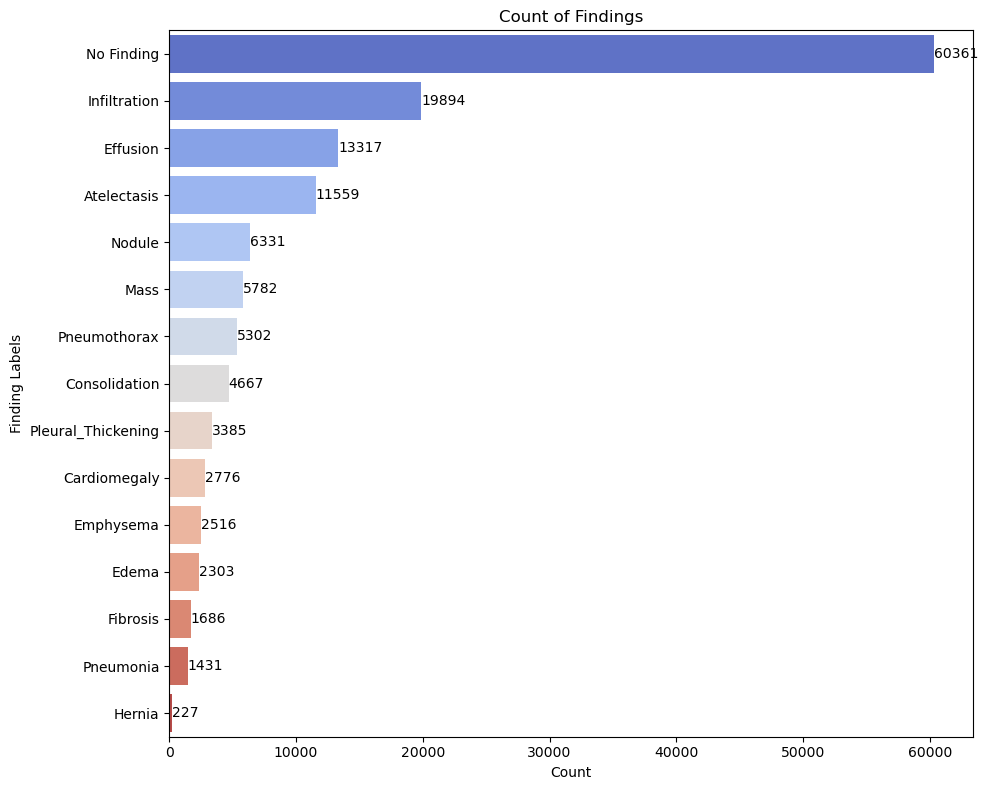

In [7]:
# Note that this only works with number of occurerences, not unique patients with a finding
plt.figure(figsize=(10, 8))

palette = sns.color_palette("coolwarm", n_colors=len(label_counts))

sns.barplot(x=label_counts.values, y=label_counts.index, orient='h', palette=palette)

plt.title('Count of Findings')
plt.xlabel('Count')
plt.ylabel('Finding Labels')

# Add count labels
for i, v in enumerate(label_counts.values):
    plt.text(v, i, str(v), va='center', ha='left', fontsize=10)

plt.tight_layout()
plt.show()

In [18]:
df.describe()

,Follow-up #,Patient ID,Patient Age,OriginalImage[Width,Height],OriginalImagePixelSpacing[x,y],Unnamed: 11
count,112120.000000,112120.000000,112120.000000,112120.000000,112120.000000,112120.000000,112120.000000,0.0
mean,8.573751,14346.381743,46.901463,2646.078844,2486.438842,0.155649,0.155649,NaN
std,15.406320,8403.876972,16.839923,341.246429,401.268227,0.016174,0.016174,NaN
min,0.000000,1.000000,1.000000,1143.000000,966.000000,0.115000,0.115000,NaN
25%,0.000000,7310.750000,35.000000,2500.000000,2048.000000,0.143000,0.143000,NaN
50%,3.000000,13993.000000,49.000000,2518.000000,2544.000000,0.143000,0.143000,NaN
75%,10.000000,20673.000000,59.000000,2992.000000,2991.000000,0.168000,0.168000,NaN
max,183.000000,30805.000000,414.000000,3827.000000,4715.000000,0.198800,0.198800,NaN


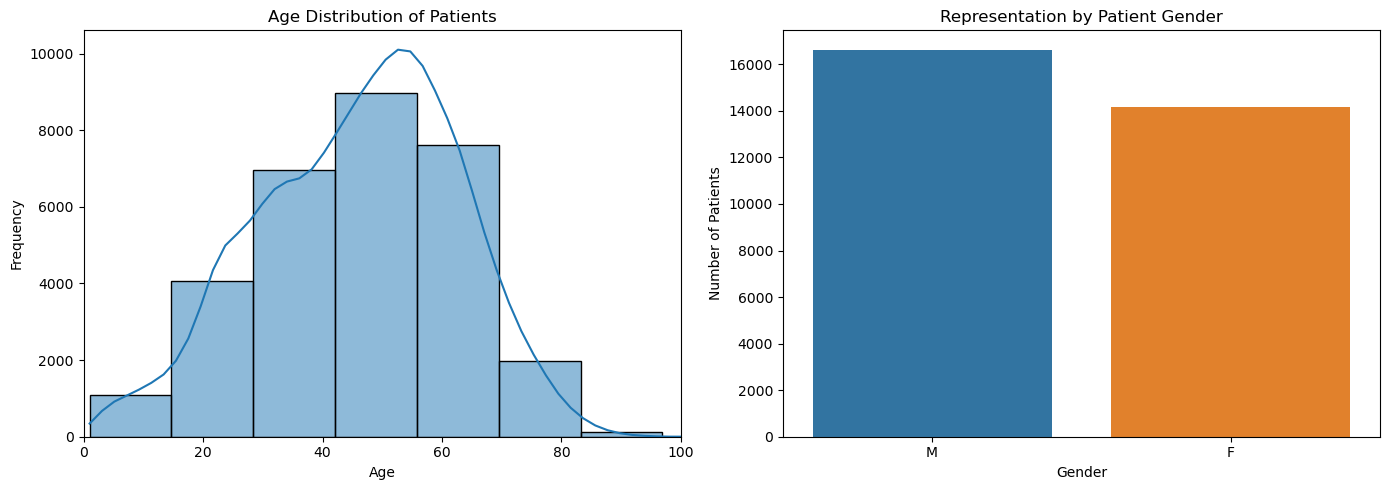

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Age Distribution
sns.histplot(df.groupby('Patient ID')['Patient Age'].first(), bins=30, kde=True, ax=axes[0])
axes[0].set_title('Age Distribution of Patients')
axes[0].set_xlabel('Age')
axes[0].set_ylabel('Frequency')
axes[0].set_xlim(0, 100)

# Gender Distribution
sns.countplot(df.groupby('Patient ID').first(), x='Patient Gender', ax=axes[1], hue='Patient Gender')
axes[1].set_title('Representation by Patient Gender')
axes[1].set_xlabel('Gender')
axes[1].set_ylabel('Number of Patients')

plt.tight_layout()  # Prevents overlapping
plt.show()

# BBox_List_2017.csv

In [9]:
bbox_df = pd.read_csv('BBox_List_2017.csv')
bbox_df.head()

,Image Index,Finding Label,Bbox [x,y,w,h],Unnamed: 6,Unnamed: 7,Unnamed: 8
0,00013118_008.png,Atelectasis,225.084746,547.019217,86.779661,79.186441,NaN,NaN,NaN
1,00014716_007.png,Atelectasis,686.101695,131.543498,185.491525,313.491525,NaN,NaN,NaN
2,00029817_009.png,Atelectasis,221.830508,317.053115,155.118644,216.949153,NaN,NaN,NaN
3,00014687_001.png,Atelectasis,726.237288,494.951420,141.016949,55.322034,NaN,NaN,NaN
4,00017877_001.png,Atelectasis,660.067797,569.780787,200.677966,78.101695,NaN,NaN,NaN


In [10]:
# Number of duplicate rows
duplicates_bbox = bbox_df.duplicated().sum()

# Total Bounding Boxes
total_bboxes = bbox_df.shape[0]

# Number of unique findings
unique_findings_bbox = bbox_df['Finding Label'].nunique()


print(f"Number of duplicate rows: {duplicates_bbox}")
print(f"Total Bounding Boxes: {total_bboxes}")
print(f"Number of unique findings: {unique_findings_bbox}")


Number of duplicate rows: 0
Total Bounding Boxes: 984
Number of unique findings: 8


In [11]:
# Number of bounding boxes per image
bbox_df['Image Index'].value_counts()

Image Index
00010277_000.png    4
00008814_010.png    3
00018253_059.png    3
00018427_004.png    3
00020482_032.png    3
                   ..
00000756_001.png    1
00008522_032.png    1
00005532_000.png    1
00030206_013.png    1
00026920_000.png    1
Name: count, Length: 880, dtype: int64

In [12]:
bbox_findings = bbox_df['Finding Label'].value_counts()
bbox_findings

Finding Label
Atelectasis     180
Effusion        153
Cardiomegaly    146
Infiltrate      123
Pneumonia       120
Pneumothorax     98
Mass             85
Nodule           79
Name: count, dtype: int64

C:\Users\Khanh Phan\AppData\Local\Temp\ipykernel_44464\1606320235.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=bbox_findings.values, y=bbox_findings.index, orient='h', palette=palette)


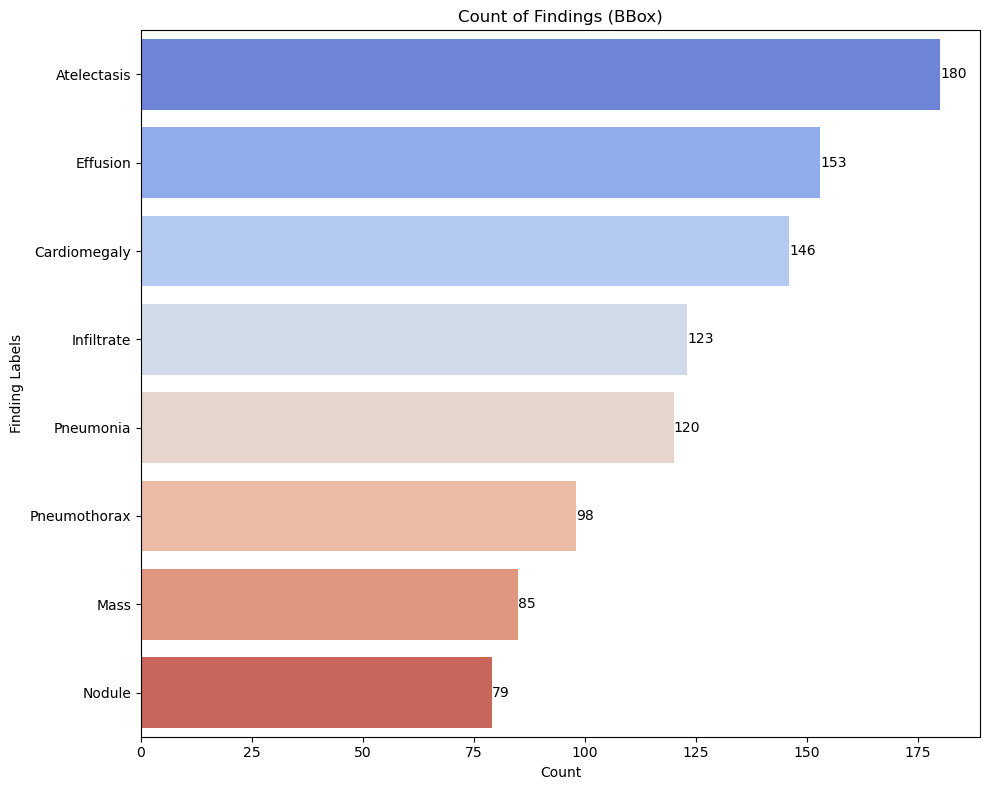

In [13]:
# Note that this only works with number of occurerences, not unique patients with a finding
plt.figure(figsize=(10, 8))

palette = sns.color_palette("coolwarm", n_colors=len(bbox_findings))

sns.barplot(x=bbox_findings.values, y=bbox_findings.index, orient='h', palette=palette)

plt.title('Count of Findings (BBox)')
plt.xlabel('Count')
plt.ylabel('Finding Labels')

# Add count labels
for i, v in enumerate(bbox_findings.values):
    plt.text(v, i, str(v), va='center', ha='left', fontsize=10)

plt.tight_layout()
plt.show()

In [17]:
bbox_df.columns

Index(['Image Index', 'Finding Label', 'Bbox [x', 'y', 'w', 'h]', 'Unnamed: 6',
       'Unnamed: 7', 'Unnamed: 8'],
      dtype='object')

In [24]:
# Tendency of pathology location heatmap
def generate_pathology_heatmap(df, label, img_size=(1024, 1024)):
    # Filter for the specific disease
    subset = df[df['Finding Label'] == label]
    heatmap = np.zeros(img_size)
    
    for _, row in subset.iterrows():
        # Add 1 to every pixel inside the bounding box
        x, y, w, h = int(row['Bbox [x']), int(row['y']), int(row['w']), int(row['h]'])
        heatmap[y:y+h, x:x+w] += 1
        
    plt.imshow(heatmap, cmap='hot')
    plt.title(f'Spatial Distribution of {label}')
    plt.colorbar()
    plt.show()


In [30]:
bbox_findings.index

Index(['Atelectasis', 'Effusion', 'Cardiomegaly', 'Infiltrate', 'Pneumonia',
       'Pneumothorax', 'Mass', 'Nodule'],
      dtype='object', name='Finding Label')

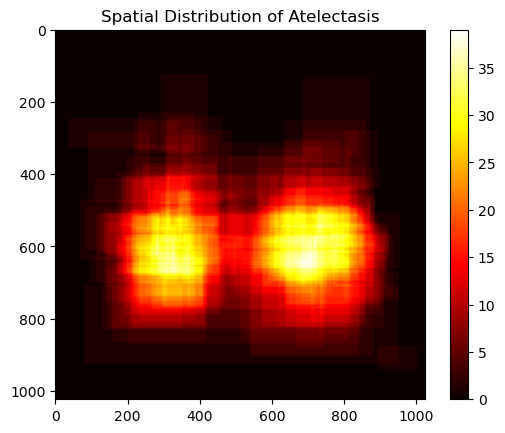

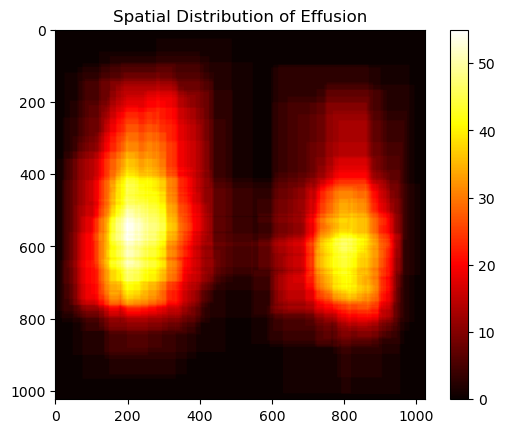

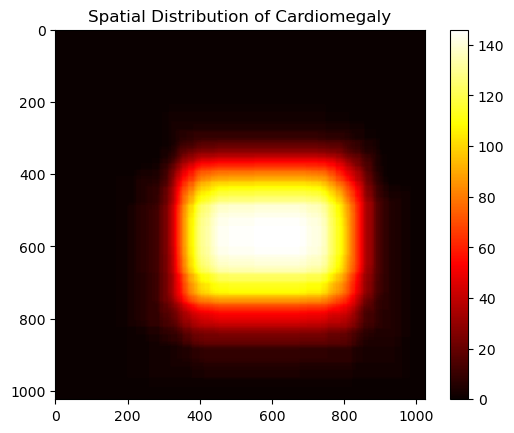

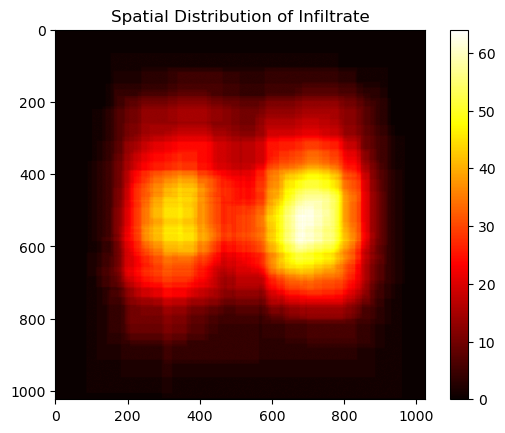

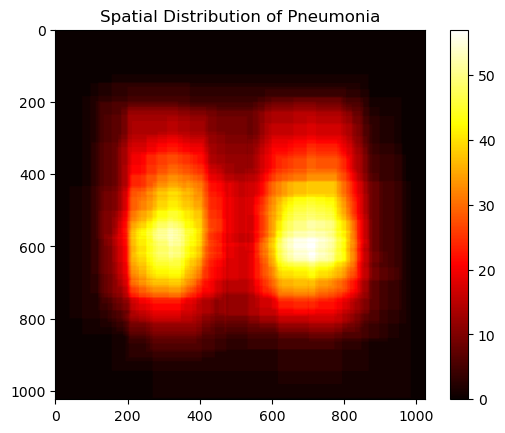

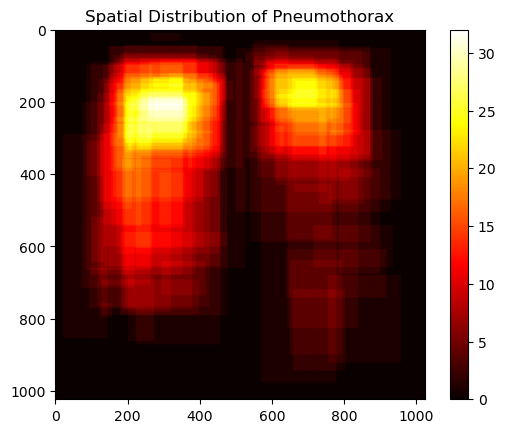

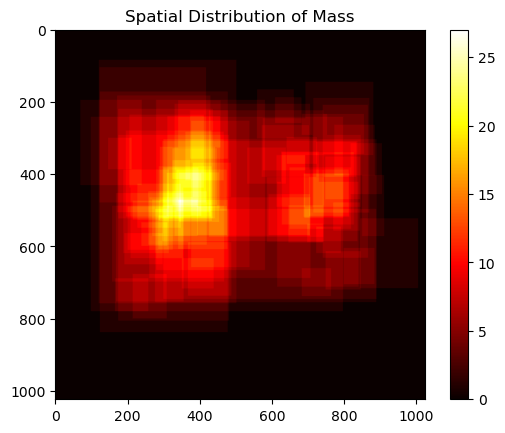

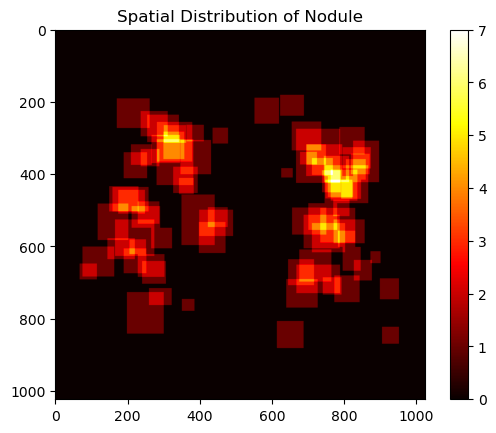

In [31]:
for finding in bbox_findings.index:
    generate_pathology_heatmap(bbox_df, finding)

<Figure size 1000x500 with 0 Axes>

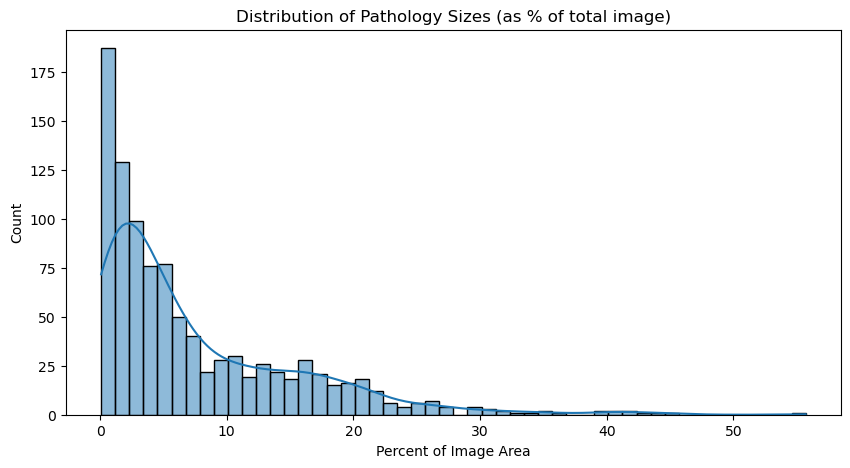

In [ ]:
# Calculate relative area ( 1024x1024 images)
bbox_df['area_percentage'] = (bbox_df['w'] * bbox_df['h]']) / (1024 * 1024) * 100

plt.figure(figsize=(10, 5))
sns.histplot(bbox_df['area_percentage'], bins=50, kde=True)
plt.title('Distribution of Pathology Sizes (as % of total image)')
plt.xlabel('Percent of Image Area')
plt.show()

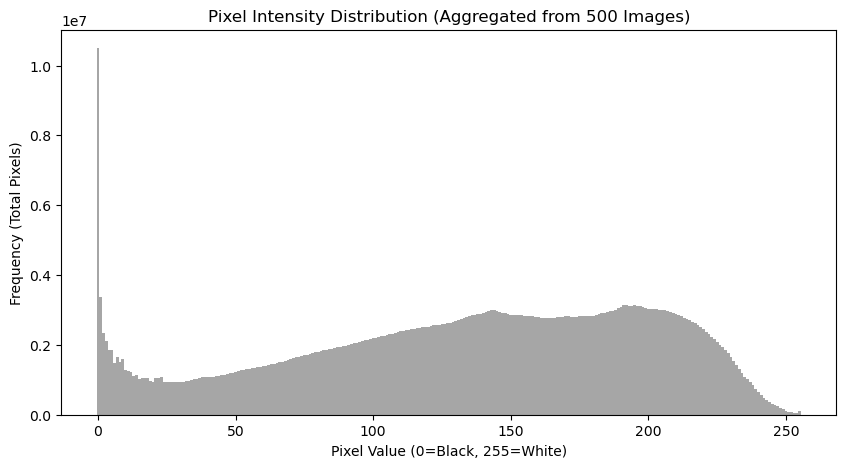

In [6]:
# Re-grab paths just in case
image_paths = glob.glob('images_001/images/*.png')[:500] 

# Initialize an empty array to hold the counts for 256 pixel values (0 to 255)
# RAM Friendly Method
total_pixel_counts = np.zeros(256, dtype=int)

for path in image_paths:
    img = cv2.imread(path, 0) 
    
    if img is not None:
        img_hist = cv2.calcHist([img], [0], None, [256], [0, 256])
        
        # Add the counts from this image to our running total
        total_pixel_counts += img_hist.flatten().astype(int)

# Plot using the PRE-CALCULATED counts
plt.figure(figsize=(10, 5))
plt.bar(range(256), total_pixel_counts, color='gray', width=1.0, alpha=0.7)
plt.title(f"Pixel Intensity Distribution (Aggregated from {len(image_paths)} Images)")
plt.xlabel("Pixel Value (0=Black, 255=White)")
plt.ylabel("Frequency (Total Pixels)")
plt.show()

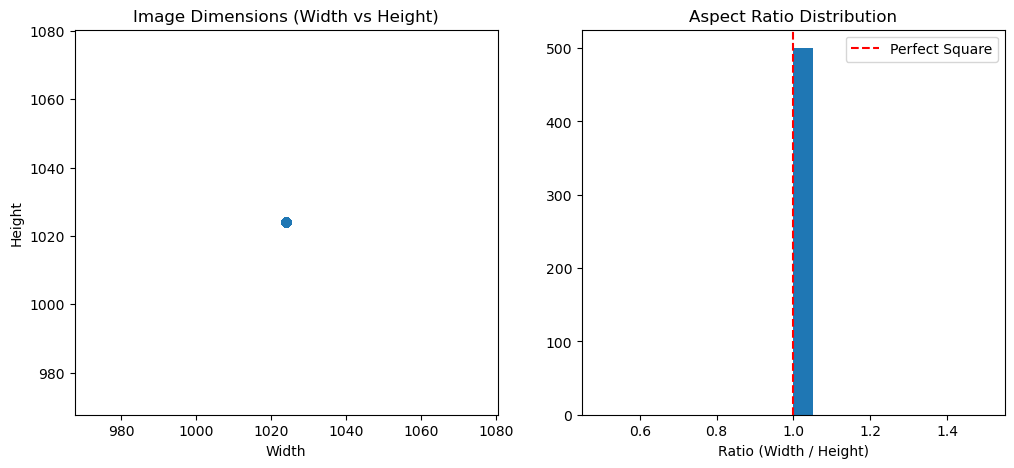

In [7]:
widths = []
heights = []
ratios = []

# Sample 1000 images
for path in image_paths[:1000]:
    img = cv2.imread(path, 0)
    if img is not None:
        h, w = img.shape
        widths.append(w)
        heights.append(h)
        ratios.append(w / h)

plt.figure(figsize=(12, 5))

# Plot 1: Scatter of Dimensions
plt.subplot(1, 2, 1)
plt.scatter(widths, heights, alpha=0.5)
plt.title("Image Dimensions (Width vs Height)")
plt.xlabel("Width")
plt.ylabel("Height")

# Plot 2: Aspect Ratio Histogram
plt.subplot(1, 2, 2)
plt.hist(ratios, bins=20)
plt.title("Aspect Ratio Distribution")
plt.xlabel("Ratio (Width / Height)")
plt.axvline(x=1.0, color='r', linestyle='--', label="Perfect Square")
plt.legend()
plt.show()

In [ ]:
# Assuming 'df' is your Data_Entry_2017 dataframe
from sklearn.model_selection import train_test_split

patients = df['Patient ID'].unique()

# Split by PATIENT, not by Image
train_patients, test_patients = train_test_split(patients, test_size=0.2, random_state=42)

# Create the actual DataFrames
train_df = df[df['Patient ID'].isin(train_patients)]
test_df = df[df['Patient ID'].isin(test_patients)]

# Verification
overlap = set(train_df['Patient ID']).intersection(set(test_df['Patient ID']))
print(f"Number of patients in both Train and Test: {len(overlap)}") 
# This MUST be 0 in order to be blinded

Number of patients in both Train and Test: 0


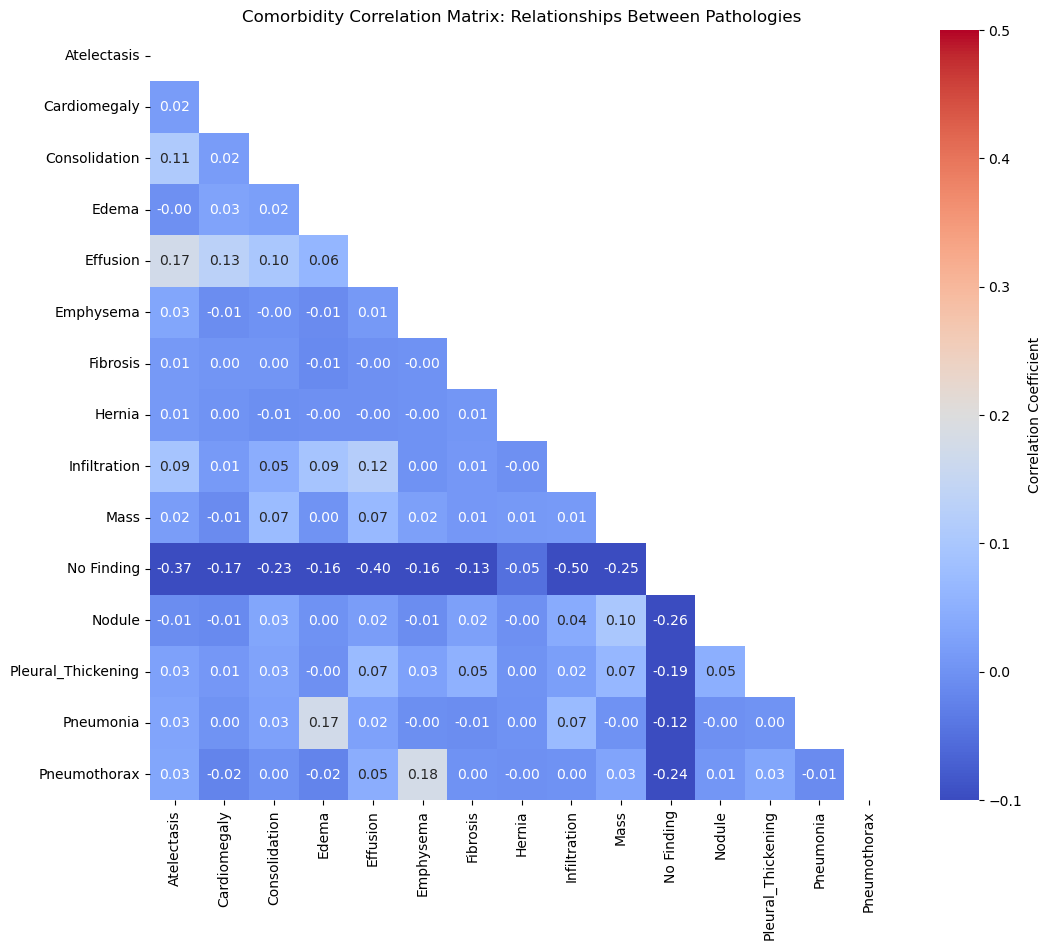

In [4]:
# Assuming 'all_labels' is a list of lists of findings for each patient
# If your df['Finding Labels'] is strings like "Infiltration|Effusion":
df['labels_list'] = df['Finding Labels'].str.split('|')
mlb = MultiLabelBinarizer()
binary_labels = mlb.fit_transform(df['labels_list'])
label_df = pd.DataFrame(binary_labels, columns=mlb.classes_)

# 2. Calculate Correlation Matrix (The "Relationship" Rubric Item)
plt.figure(figsize=(12, 10))
corr_matrix = label_df.corr()

# Mask the diagonal (because everything correlates 1.0 with itself)
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(corr_matrix, annot=True, fmt=".2f", mask=mask, 
            cmap='coolwarm', vmin=-0.1, vmax=0.5, cbar_kws={'label': 'Correlation Coefficient'})
plt.title("Comorbidity Correlation Matrix: Relationships Between Pathologies")
plt.show()